**Problemas de Astroestadística**

**Problem set 7: Inferencia Bayesiana**

Astronomía - Universidad de Antioquia

Contenido: 1) Inferencia sobre proporción de exoplanetas; 2) Modelo de Cefeidas (periodo–luminosidad).

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
from scipy import stats

## **Punto 1**

Un equipo de astrónomos estudia la frecuencia de exoplanetas detectables mediante el método de tránsito en estrellas similares al Sol. Para ello, observa una muestra aleatoria de $n = 100$ estrellas y encuentra evidencia de detección en $X = 18$ de ellas.

Sea $\theta$ la proporción verdadera de estrellas de esta población que poseen un exoplaneta detectable por tránsito. Suponiendo ensayos de Bernoulli independientes, el número total de detecciones sigue

$$X \sim \mathrm{Binomial}(n,\theta),\qquad n=100,\; X=18.$$

Estudios previos sugieren que $\approx 20\%$ de las estrellas similares al Sol albergan exoplanetas detectables por tránsito; para incorporar esto se usa la a priori

$$\theta \sim \mathrm{Beta}(\alpha,\beta),\qquad \alpha=4,\;\beta=16.$$


a) Escriba la función de verosimilitud para $\theta$ y grafíquela en $0<\theta<1$ (escriba la forma funcional y marque el rango).

b) Escriba la densidad de la distribución a priori e interprete el significado de los parámetros $\alpha$ y $\beta$.

c) Obtenga analíticamente la distribución posterior de $\theta$ (muestre la conjugación Beta–Binomial).

d) Calcule la media, la varianza y la moda de la distribución posterior (exprese en términos de $\alpha,\beta,n,X$).

e) Utilice simulación Monte Carlo para generar $10^4$ muestras aleatorias de la distribución posterior.

f) A partir de las muestras simuladas, estime un intervalo de credibilidad del $95\%$ para $\theta$.

g) Estime la probabilidad posterior de que más del $20\%$ de las estrellas posean un exoplaneta detectable, es decir $P(\theta>0.20\mid\mathrm{datos})$.

h) Compare la interpretación del intervalo de credibilidad obtenido con la interpretación de un intervalo de confianza frecuentista del $95\%$.

In [3]:
# posterior 

alpha = 22
beta = 98

stats.beta.mean(alpha, beta)

np.float64(0.18333333333333332)

In [4]:
post_moda = (alpha - 1) / (alpha + beta - 2)
post_moda

0.17796610169491525

In [5]:
var_post = (alpha * beta) / ((alpha + beta) ** 2 * (alpha + beta + 1))
var_post

0.0012373737373737373

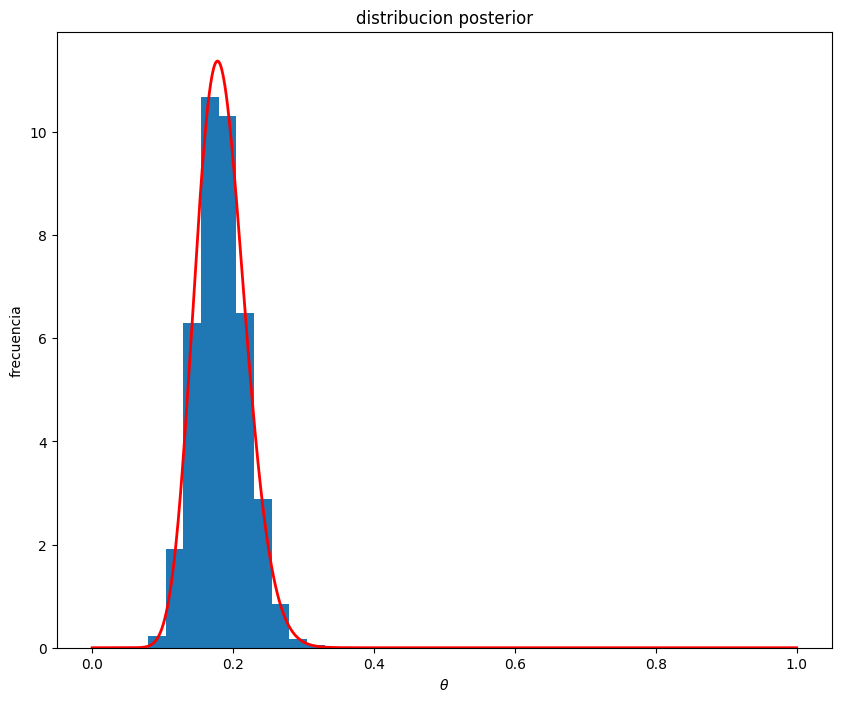

In [6]:
# generamos numeros aleatorios que sigan la distribucion posterior

porsterior_samples = np.random.beta(alpha, beta, 10000)
plt.figure(figsize=(10,8))
plt.hist(porsterior_samples, bins=10, density=True)
plt.plot(np.linspace(0, 1, 1000), stats.beta.pdf(np.linspace(0, 1, 1000), alpha, beta), 'r-', linewidth=2)
plt.xlabel(r'$\theta$')
plt.ylabel('frecuencia')
plt.title('distribucion posterior')
plt.show()

In [7]:
np.percentile(porsterior_samples, [2.5, 97.5])

array([0.11854974, 0.25599096])

## **Punto 2**

**Modelo de estrellas variables.**

Se adjunta el archivo `cepheids_2.csv`, que contiene observaciones de un conjunto de estrellas Cefeidas (Breuval+, 2021). Para cada estrella se reportan su período de pulsación $P$ (en días), paralaje (mas) y magnitudes en V e I. La relación periodo–luminosidad puede modelarse como:

$$M_i = a + b\log_{10}(P_i) + \varepsilon_i,\qquad \varepsilon_i \sim N(0,\sigma^2),$$

donde $\sigma$ es conocido e igual a $0.3$ mag. Se usan priors independientes:

$$a\sim N(0,10^2),\qquad b\sim N(0,10^2).$$


a) Lea `cepheids_2.csv` y realice un gráfico de dispersión de $M$ vs $\log_{10}(P)$. Describa la tendencia.

In [8]:
# Carga de datos
df = pd.read_csv(
    "mw_cepheids.csv",
    skiprows=[1, 2],       # salta la fila de unidades y la fila separadora
    skipinitialspace=True   # quita espacios después de las comas
)

# Limpieza de nombres de columnas
df.columns = [col.strip().lstrip("_") for col in df.columns]

# Convertir columnas relevantes a numéricas, manejando errores
for col in ["RAJ2000", "DEJ2000", "Per", "plx", "Vmag", "Imag"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()

,RAJ2000,DEJ2000,Per,plx,Vmag,Imag
0,91.645609,26.329223,11.302,0.311,9.735,NaN
1,105.249250,-8.708992,8.014,0.383,10.100,8.708
2,100.781299,20.939111,3.788,0.370,NaN,NaN
3,117.016047,-25.577784,13.596,0.254,9.898,8.716
4,144.214443,-53.032797,7.134,0.369,10.257,8.730


In [17]:
df["logP"] = np.log10(df["Per"])
df["M_V"] = df["Vmag"] + 5*np.log10(df["plx"]) - 1
df["M_I"] = df["Imag"] + 5*np.log10(df["plx"]) - 1

In [18]:
df.head()

,RAJ2000,DEJ2000,Per,plx,Vmag,Imag,logP,M_V,M_I
0,91.645609,26.329223,11.302,0.311,9.735,NaN,1.053155,6.198802,NaN
1,105.249250,-8.708992,8.014,0.383,10.100,8.708,0.903849,7.015994,5.623994
2,100.781299,20.939111,3.788,0.370,NaN,NaN,0.578410,NaN,NaN
3,117.016047,-25.577784,13.596,0.254,9.898,8.716,1.133411,5.922169,4.740169
4,144.214443,-53.032797,7.134,0.369,10.257,8.730,0.853333,7.092132,5.565132


In [20]:
df_clean = df[["logP", "M_V", "M_I"]].dropna()

df_clean.head()

,logP,M_V,M_I
1,0.903849,7.015994,5.623994
3,1.133411,5.922169,4.740169
4,0.853333,7.092132,5.565132
5,0.583992,6.626346,5.744346
6,0.706206,6.213360,5.291360


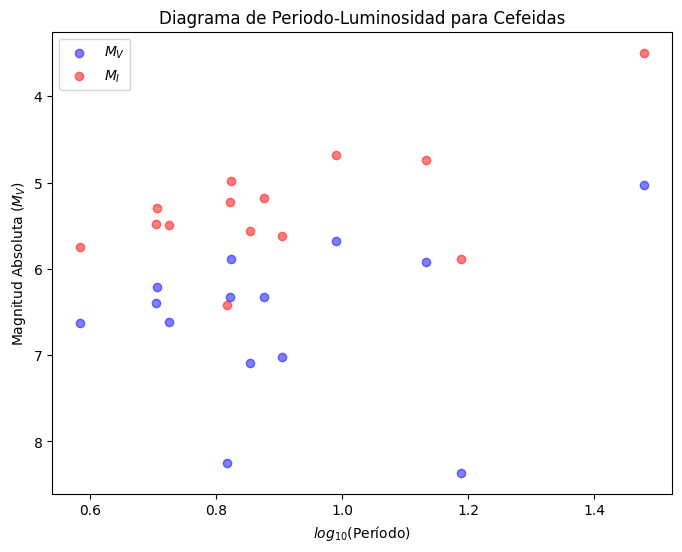

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clean["logP"], df_clean["M_V"], color="blue", alpha=0.5, label=r"$M_V$")
plt.scatter(df_clean["logP"], df_clean["M_I"], color="red", alpha=0.5, label=r"$M_I$")
plt.xlabel(r"$log_{{10}}$(Período)")
plt.ylabel(r"Magnitud Absoluta ($M_V$)")
plt.title("Diagrama de Periodo-Luminosidad para Cefeidas")
plt.gca().invert_yaxis()  # Invertir el eje y para que las estrellas más brillantes estén arriba
plt.legend()
plt.show()

b) Escriba la función de verosimilitud para los parámetros $a$ y $b$.

Como $\epsilon_i$ es una variable aleatoria normal con media $0$ y varianza $\sigma^2$, si le sumamos la parte determinista ($a + b x_i$) con $x_i = \log_{10}(P_i)$, la magnitud absoluta medida $M_i$ pasa a ser una variable aleatoria normal cuya media se desplaza a la posición de la recta. Es decir:$$M_i \sim N(a + b x_i, \, \sigma^2)$$La función de densidad de probabilidad (PDF) de una distribución Normal para este dato individual $M_i$, dados los parámetros estructurales $a$ y $b$, se escribe formalmente como:$$P(M_i \mid a, b, x_i) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(M_i - (a + b x_i))^2}{2\sigma^2} \right)$$

c) Escriba la distribución posterior conjunta de $a$ y $b$ (ignorando constantes de normalización).

d) Encuentre los valores MAP de $a$ y $b$.

e) Demuestre que la posterior conjunta de $(a,b)$ es una normal bivariada y determine su media y matriz de covarianza.

f) Genere $10^4$ muestras aleatorias de la posterior conjunta de $(a,b)$.

g) A partir de las muestras, estime un intervalo de credibilidad del $95\%$ para $a$ y $b$.

h) Utilice las muestras para estimar la distribución posterior de la magnitud absoluta de una Cefeida con $P=12$ días; reporte la media posterior y un intervalo de credibilidad del $95\%$.

i) Grafique la relación periodo–luminosidad usando la recta MAP y una banda de credibilidad del $95\%$ obtenida por simulación.

j) Compare los resultados bayesianos con una regresión lineal por mínimos cuadrados; discuta semejanzas y diferencias.